In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load your dataset
data = pd.read_csv('./solar_radiation.csv')

# Convert month to numeric values
month_mapping = {month: idx for idx, month in enumerate(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])}
data['month'] = data['month'].map(month_mapping)

# Verify month column
print(data['month'].unique())  # Should show values from 0 to 11

# Normalize Features
features = ['H(h)_m', 'H(i_opt)_m', 'H(i)_m', 'Hb(n)_m', 'Kd', 'T2m']
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Define target variable and features
X = data[['H(h)_m', 'H(i_opt)_m', 'H(i)_m', 'Hb(n)_m', 'Kd', 'T2m', 'month']]
y = data['H(h)_m']  # Replace with your actual target column name

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

[ 0  1  2  3  4  5  6  7  8  9 10 11]


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, LayerNormalization, MultiHeadAttention, Dropout, Flatten, Concatenate, Reshape, GlobalAveragePooling1D
from tensorflow.keras.models import Model

def build_transformer_model(input_shape):
    # Define inputs
    feature_inputs = Input(shape=input_shape, name='features')
    month_inputs = Input(shape=(1,), dtype='int32', name='month')
    
    # Embedding layer for month
    month_embedding = Embedding(input_dim=12, output_dim=8)(month_inputs)
    
    # Flatten the month embedding to be concatenated
    month_embedding = Flatten()(month_embedding)
    
    # Combine numerical features with month embeddings
    x = Concatenate()([feature_inputs, month_embedding])
    
    # Adding a transformer-like block
    x = Dense(128, activation='relu')(x)
    x = LayerNormalization()(x)
    x = Reshape((1, -1))(x)  # Reshape for MultiHeadAttention
    
    attention_output = MultiHeadAttention(
        num_heads=8,
        key_dim=64
    )(query=x, value=x, key=x)  # Using query, key, and value as x

    x = Dropout(0.1)(attention_output)
    x = Dense(64, activation='relu')(x)
    x = GlobalAveragePooling1D()(x)  # Ensure x is 3D for this layer
    x = Dense(1)(x)
    
    model = Model(inputs=[feature_inputs, month_inputs], outputs=x)
    model.compile(optimizer='adam', loss='mse')
    
    return model

# Define model input shapes
input_shape = (X_train.shape[1] - 1, )  # Exclude month column
model = build_transformer_model(input_shape)

In [3]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=10)
]

# Ensure the month column in X_train and X_test are of integer type
X_train['month'] = X_train['month'].astype(np.int32)
X_test['month'] = X_test['month'].astype(np.int32)

history = model.fit(
    [X_train.drop(columns='month'), X_train['month']],
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/50


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.3718 - val_loss: 0.0667 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0929 - val_loss: 0.0946 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0640 - val_loss: 0.0264 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0274 - val_loss: 0.0289 - learning_rate: 0.0010
Epoch 5/50
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0177

/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0183 - val_loss: 0.0196 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0227 - val_loss: 0.0292 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0259 - val_loss: 0.0183 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0143 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0075 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0075 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0055 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0052 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 13/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0052 - val_loss: 7.5612e-04 - learning_rate: 0.0010
Epoch 14/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/st

In [4]:
test_loss = model.evaluate([X_test.drop(columns='month'), X_test['month']], y_test)
print(f'Test Loss: {test_loss}')

predictions = model.predict([X_test.drop(columns='month'), X_test['month']])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.8508e-04 
Test Loss: 0.00048226548824459314
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


In [5]:
# Make predictions on the test set
y_pred = model.predict([X_test.drop(columns='month'), X_test['month']])

# Show the first few predictions and actual values
import pandas as pd

# Combine predictions and actual values for comparison
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred.flatten()
})

print(results.head())

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
       Actual  Predicted
45   0.405780   0.391150
136  0.874167   0.857707
76   0.911049   0.887387
143  0.079575   0.066369
113  0.756625   0.735856


In [6]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Make predictions on the test set
y_pred = model.predict([X_test.drop(columns='month'), X_test['month']])

# Show the first few predictions and actual values
import pandas as pd

# Combine predictions and actual values for comparison
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred.flatten()
})

print(results.head())

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
       Actual  Predicted
45   0.405780   0.391150
136  0.874167   0.857707
76   0.911049   0.887387
143  0.079575   0.066369
113  0.756625   0.735856


In [7]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate Mean Absolute Error and R-squared
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")
print(f"RMSE: {rmse}")

Mean Absolute Error: 0.018587877678656873
R-squared: 0.9926048522523964
RMSE: 0.021960542785732215


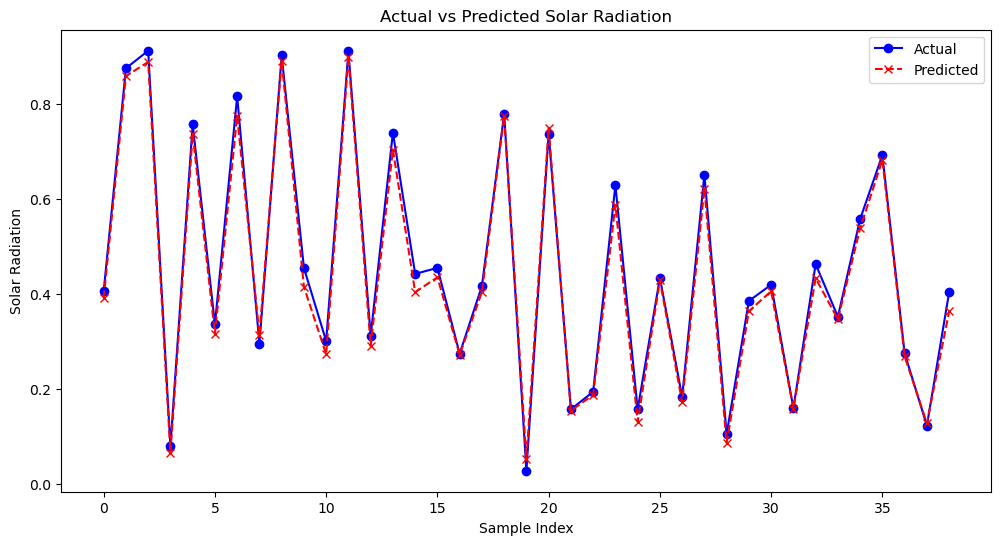

In [8]:
import matplotlib.pyplot as plt

# Plotting Actual vs Predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(y_pred, label='Predicted', color='red', linestyle='--', marker='x')
plt.xlabel('Sample Index')
plt.ylabel('Solar Radiation')
plt.title('Actual vs Predicted Solar Radiation')
plt.legend()
plt.show()

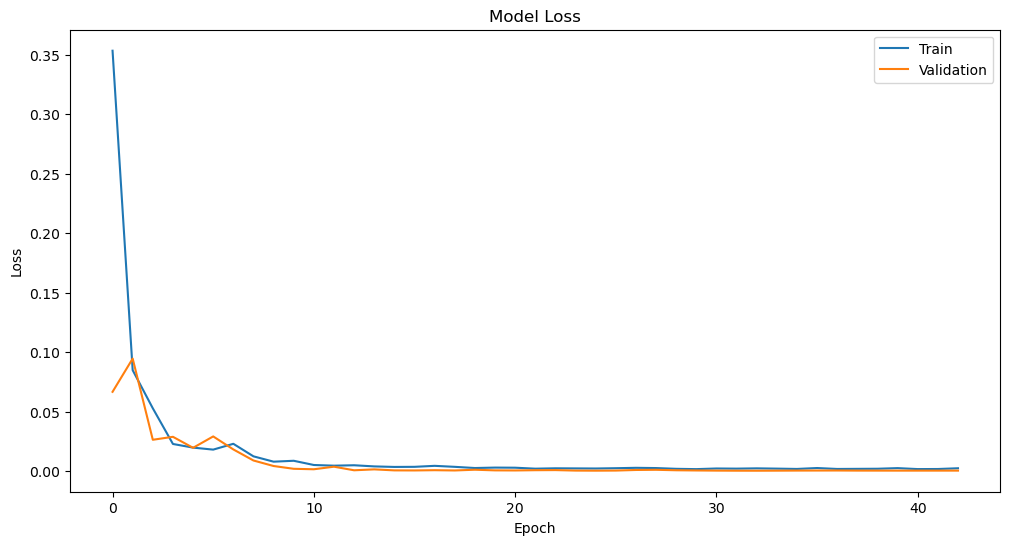

In [9]:
# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

## COMPARISON WITH ADAM OPTIMIZER

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, LayerNormalization, MultiHeadAttention, Dropout, Flatten, Concatenate, Reshape, GlobalAveragePooling1D, Conv1D, MaxPooling1D, SimpleRNN, LSTM
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load your dataset
data = pd.read_csv('./solar_radiation.csv')

# Convert month to numeric values
month_mapping = {month: idx for idx, month in enumerate(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])}
data['month'] = data['month'].map(month_mapping)

# Normalize Features
features = ['H(h)_m', 'H(i_opt)_m', 'H(i)_m', 'Hb(n)_m', 'Kd', 'T2m']
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Define target variable and features
X = data[['H(h)_m', 'H(i_opt)_m', 'H(i)_m', 'Hb(n)_m', 'Kd', 'T2m', 'month']]
y = data['H(h)_m']  # Replace with your actual target column name

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape for CNN, RNN, and LSTM models
X_train_reshaped = X_train.drop(columns='month').values.reshape(X_train.shape[0], X_train.shape[1]-1, 1)
X_test_reshaped = X_test.drop(columns='month').values.reshape(X_test.shape[0], X_test.shape[1]-1, 1)

# Callbacks for early stopping and learning rate reduction
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
]

## CNN MODEL

In [12]:
def build_cnn_model(input_shape):
    model = tf.keras.Sequential([
        Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

cnn_model = build_cnn_model((X_train_reshaped.shape[1], 1))
history_cnn = cnn_model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=callbacks)
y_pred_cnn = cnn_model.predict(X_test_reshaped)

Epoch 1/50


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1970 - val_loss: 0.0989 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0973 - val_loss: 0.0676 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0787 - val_loss: 0.0738 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0793 - val_loss: 0.0669 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0653 - val_loss: 0.0514 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0544 - val_loss: 0.0428 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0480 - val_loss: 0.0396 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0472 - val_loss: 0.0346 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0358 - val_loss: 0.0295 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss:

## RNN MODEL

In [13]:
def build_rnn_model(input_shape):
    model = tf.keras.Sequential([
        SimpleRNN(64, input_shape=input_shape),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

rnn_model = build_rnn_model((X_train_reshaped.shape[1], 1))
history_rnn = rnn_model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=callbacks)
y_pred_rnn = rnn_model.predict(X_test_reshaped)

Epoch 1/50


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1669 - val_loss: 0.0562 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0607 - val_loss: 0.0286 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0269 - val_loss: 0.0161 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0143 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0052 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 - val_loss: 7.8238e-04 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.6483e-04 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/ste

## LSTM MODEL

In [14]:
def build_lstm_model(input_shape):
    model = tf.keras.Sequential([
        LSTM(64, input_shape=input_shape),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_model = build_lstm_model((X_train_reshaped.shape[1], 1))
history_lstm = lstm_model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=callbacks)
y_pred_lstm = lstm_model.predict(X_test_reshaped)

Epoch 1/50


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.2027 - val_loss: 0.1502 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1504 - val_loss: 0.1038 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1068 - val_loss: 0.0681 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0609 - val_loss: 0.0474 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0504 - val_loss: 0.0521 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0498 - val_loss: 0.0556 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0525 - val_loss: 0.0474 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0470 - val_loss: 0.0434 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0464 - val_loss: 0.0435 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss:

## PERFORMANCE METRICS

CNN - MAE: 0.008289089997972988, R2: 0.9984166657180529, RMSE: 0.010161456212973765
RNN - MAE: 0.024198884714682685, R2: 0.9847918167643323, RMSE: 0.03149258503956118
LSTM - MAE: 0.16065030906706176, R2: 0.3856405711660488, RMSE: 0.20016166571554833
Transformer - MAE: 0.018587877678656873, R2: 0.9926048522523964, RMSE: 0.021960542785732215


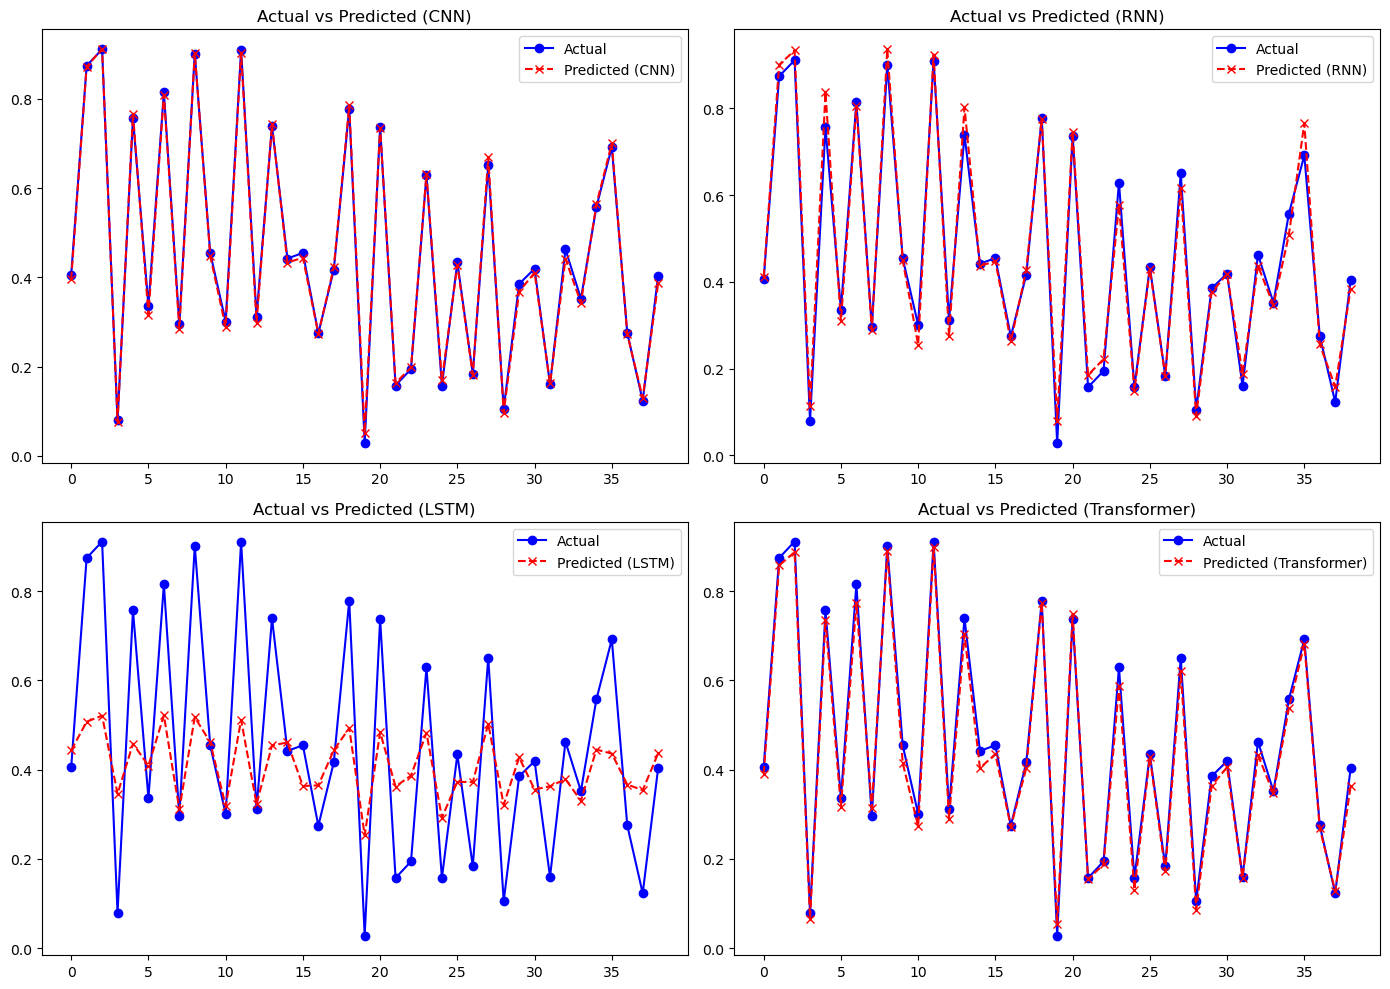

In [15]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Calculate RMSE
    return mae, r2, rmse

# Calculate evaluation metrics for each model
mae_cnn, r2_cnn, rmse_cnn = evaluate_model(y_test, y_pred_cnn)
mae_rnn, r2_rnn, rmse_rnn = evaluate_model(y_test, y_pred_rnn)
mae_lstm, r2_lstm, rmse_lstm = evaluate_model(y_test, y_pred_lstm)
mae_transformer, r2_transformer, rmse_transformer = evaluate_model(y_test, y_pred)

# Print results
print(f"CNN - MAE: {mae_cnn}, R2: {r2_cnn}, RMSE: {rmse_cnn}")
print(f"RNN - MAE: {mae_rnn}, R2: {r2_rnn}, RMSE: {rmse_rnn}")
print(f"LSTM - MAE: {mae_lstm}, R2: {r2_lstm}, RMSE: {rmse_lstm}")
print(f"Transformer - MAE: {mae_transformer}, R2: {r2_transformer}, RMSE: {rmse_transformer}")

# Plotting Actual vs Predicted for all models
plt.figure(figsize=(14, 10))

# CNN Plot
plt.subplot(2, 2, 1)
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(y_pred_cnn, label='Predicted (CNN)', color='red', linestyle='--', marker='x')
plt.title(f'Actual vs Predicted (CNN)')
plt.legend()

# RNN Plot
plt.subplot(2, 2, 2)
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(y_pred_rnn, label='Predicted (RNN)', color='red', linestyle='--', marker='x')
plt.title(f'Actual vs Predicted (RNN)')
plt.legend()

# LSTM Plot
plt.subplot(2, 2, 3)
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(y_pred_lstm, label='Predicted (LSTM)', color='red', linestyle='--', marker='x')
plt.title(f'Actual vs Predicted (LSTM)')
plt.legend()

# Transformer Plot
plt.subplot(2, 2, 4)
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(y_pred, label='Predicted (Transformer)', color='red', linestyle='--', marker='x')
plt.title(f'Actual vs Predicted (Transformer)')
plt.legend()

plt.tight_layout()
plt.show()

## HYBRIDS

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.1820 - val_loss: 0.1228
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1318 - val_loss: 0.0791
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1255 - val_loss: 0.0636
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0804 - val_loss: 0.0582
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0663 - val_loss: 0.0619
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0561 - val_loss: 0.0455
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0590 - val_loss: 0.0369
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0433 - val_loss: 0.0245
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0269 - val_loss: 0.0176
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0283 - val_loss: 0.0111
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0143 - val_loss: 0.0097
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0163 - val_loss: 0.0070
Epoch 13/50


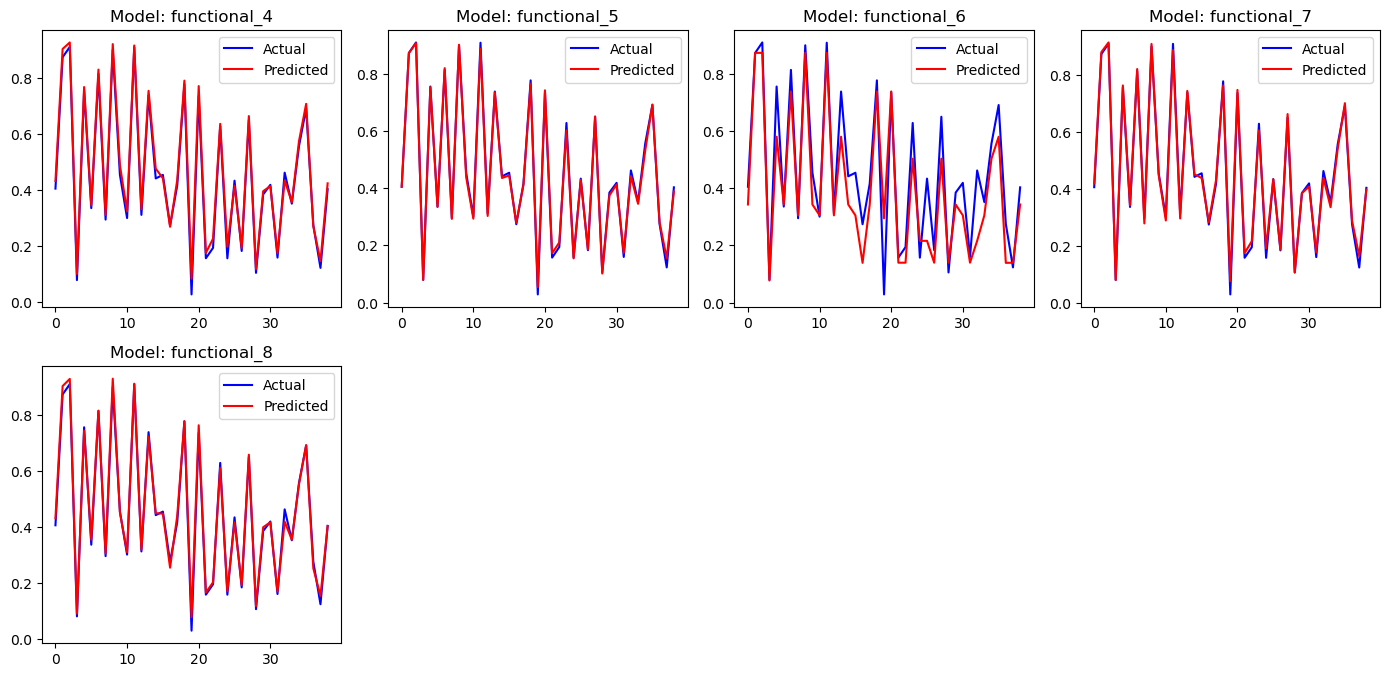

In [16]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Conv1D, MaxPooling1D, Flatten, Embedding, MultiHeadAttention, LayerNormalization, Dropout, Reshape
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Define all hybrid models

def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_out = LSTM(64)(inputs)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    combined = tf.keras.layers.concatenate([lstm_out, transformer_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model


def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_out = LSTM(64)(inputs)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    combined = tf.keras.layers.concatenate([lstm_out, cnn_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model


def build_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    transformer_out = Reshape((1, transformer_out.shape[1]))(transformer_out)
    lstm_out = LSTM(64)(transformer_out)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    output = Dense(1)(lstm_out)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model


def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    lstm_out = LSTM(64)(inputs)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    
    combined = tf.keras.layers.concatenate([cnn_out, lstm_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model


def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    combined = tf.keras.layers.concatenate([cnn_out, transformer_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model


# Evaluate Model Performance
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Calculate RMSE
    return mae, r2, rmse

# Prepare your data (X_train, y_train, X_test, y_test should be ready)

# Reshaping the input data to match the expected input shape for LSTM/CNN/Transformer models
X_train_reshaped = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)  # Reshape to (samples, timesteps, features)
X_test_reshaped = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)  # Reshape to (samples, timesteps, features)

models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    # Add other hybrid models here
]

results = {'Model': [], 'RMSE': [], 'MAE': [], 'R-Square': []}

for model in models:
    model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2)
    y_pred = model.predict(X_test_reshaped)
    
    mae, r2, rmse = evaluate_model(y_test, y_pred)
    
    results['Model'].append(model.name)
    results['RMSE'].append(rmse)
    results['MAE'].append(mae)
    results['R-Square'].append(r2)

# Display the results
for i in range(len(results['Model'])):
    print(f"Model: {results['Model'][i]} - MAE: {results['MAE'][i]}, R2: {results['R-Square'][i]}, RMSE: {results['RMSE'][i]}")

# Plotting Actual vs Predicted for all models
plt.figure(figsize=(14, 10)) 
for i, model in enumerate(models):
    y_pred = model.predict(X_test_reshaped)
    plt.subplot(3, 4, i + 1)
    plt.plot(y_test.values, label='Actual', color='blue')
    plt.plot(y_pred, label='Predicted', color='red')
    plt.title(f"Model: {model.name}")
    plt.legend()

plt.tight_layout()
plt.show()


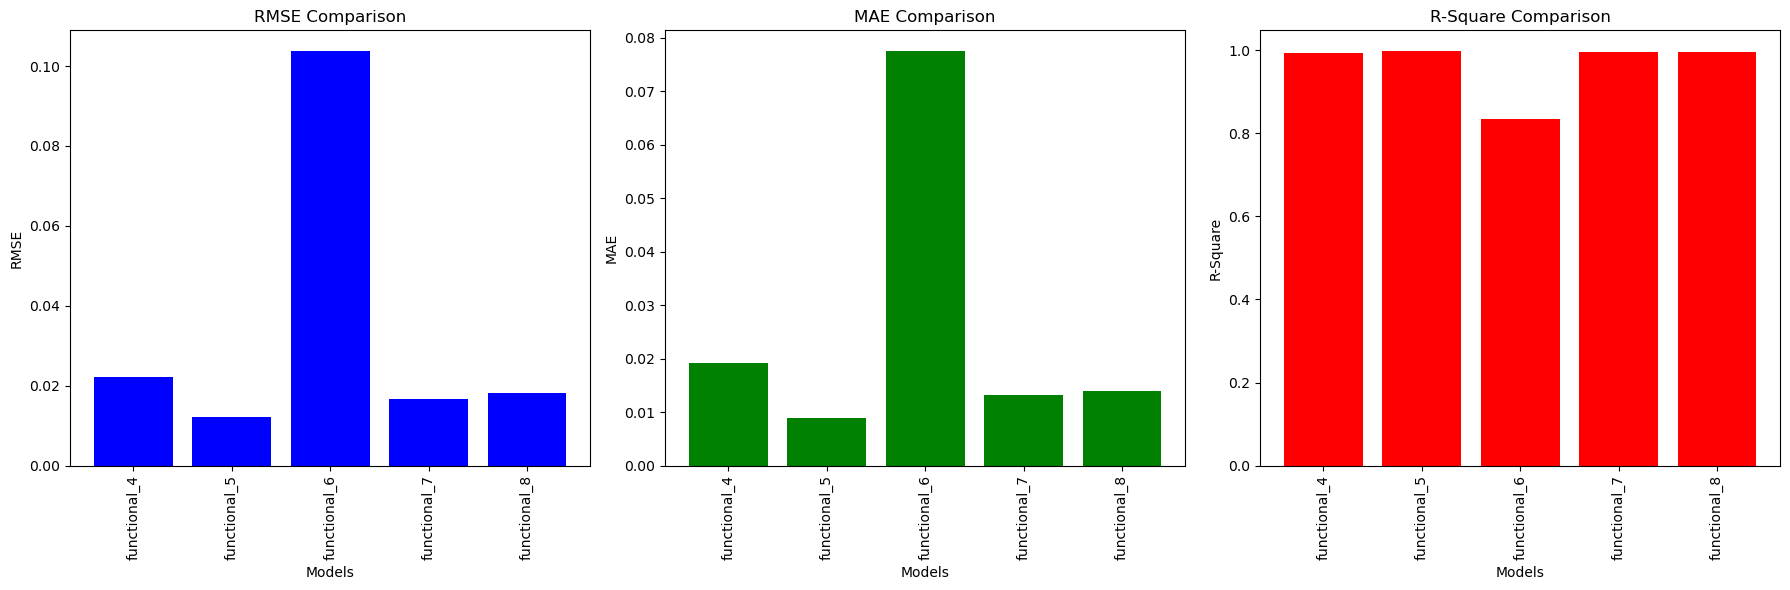

In [17]:
import matplotlib.pyplot as plt

# Assuming 'results' dictionary contains the evaluation metrics for each model:
# results = {'Model': [], 'RMSE': [], 'MAE': [], 'R-Square': []}

# Plotting Bar plots for RMSE, MAE, and R-Square

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# RMSE Plot
axs[0].bar(results['Model'], results['RMSE'], color='blue')
axs[0].set_title('RMSE Comparison')
axs[0].set_xlabel('Models')
axs[0].set_ylabel('RMSE')
axs[0].tick_params(axis='x', rotation=90)  # Rotate model names for better readability

# MAE Plot
axs[1].bar(results['Model'], results['MAE'], color='green')
axs[1].set_title('MAE Comparison')
axs[1].set_xlabel('Models')
axs[1].set_ylabel('MAE')
axs[1].tick_params(axis='x', rotation=90)  # Rotate model names for better readability

# R-Square Plot
axs[2].bar(results['Model'], results['R-Square'], color='red')
axs[2].set_title('R-Square Comparison')
axs[2].set_xlabel('Models')
axs[2].set_ylabel('R-Square')
axs[2].tick_params(axis='x', rotation=90)  # Rotate model names for better readability

# Adjust the layout and show the plots
plt.tight_layout()
plt.show()


Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.0132e-04 - val_loss: 5.1495e-04
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.3236e-04 - val_loss: 2.3037e-04
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.4393e-04 - val_loss: 7.0235e-04
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.4567e-04 - val_loss: 3.8822e-04
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.3237e-04 - val_loss: 2.6803e-04
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.3210e-04 - val_loss: 4.6706e-04
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.2633e-04 - val_loss: 4.3113e-04
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.6739e-04 - val_loss: 3.2066e-04
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.6104e-04 - val_loss: 3.6724e-04
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.1182e-04 - val_loss: 7.4043e-04
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.0927e-04 - val_loss: 2.5748e-04
Epoch 1

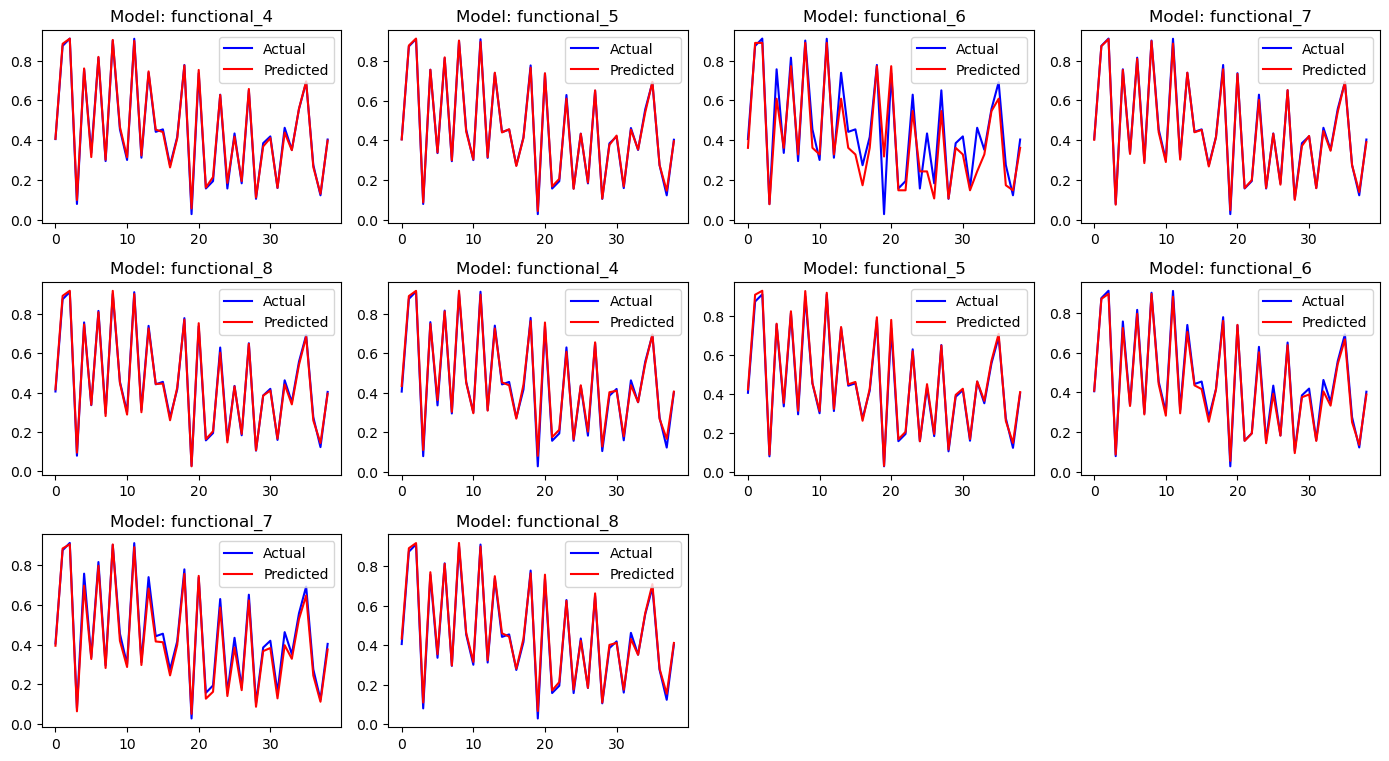

In [18]:
# Define the missing hybrid models

def build_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    combined = tf.keras.layers.concatenate([transformer_out, cnn_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    lstm_out = LSTM(64)(inputs)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    combined = tf.keras.layers.concatenate([cnn_out, lstm_out, transformer_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def build_lstm_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    
    lstm_out = LSTM(64)(inputs)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    combined = tf.keras.layers.concatenate([lstm_out, cnn_out, transformer_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def build_cnn_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    lstm_out = LSTM(64)(inputs)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    
    combined = tf.keras.layers.concatenate([cnn_out, transformer_out, lstm_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def build_lstm_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    
    lstm_out = LSTM(64)(inputs)
    lstm_out = Dense(32, activation='relu')(lstm_out)
    
    transformer_input = Embedding(input_dim=1000, output_dim=32)(inputs)
    transformer_out = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
    transformer_out = LayerNormalization()(transformer_out)
    transformer_out = Dropout(0.1)(transformer_out)
    transformer_out = Flatten()(transformer_out)
    transformer_out = Dense(32, activation='relu')(transformer_out)
    
    cnn_out = Conv1D(64, 3, activation='relu')(inputs)
    cnn_out = MaxPooling1D(2)(cnn_out)
    cnn_out = Flatten()(cnn_out)
    cnn_out = Dense(32, activation='relu')(cnn_out)
    
    combined = tf.keras.layers.concatenate([lstm_out, transformer_out, cnn_out])
    output = Dense(1)(combined)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Add models to the list
models.extend([
    build_transformer_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_lstm_transformer_cnn((X_train_reshaped.shape[1], 1)),
])

# Evaluate all models
for model in models:
    model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2)
    y_pred = model.predict(X_test_reshaped)
    mae, r2, rmse = evaluate_model(y_test, y_pred)
    results['Model'].append(model.name)
    results['RMSE'].append(rmse)
    results['MAE'].append(mae)
    results['R-Square'].append(r2)

# Final comparison table
import pandas as pd

results_df = pd.DataFrame(results)
results_df.sort_values(by='RMSE', inplace=True)
print("Model Performance Comparison:")
print(results_df)

# Final Plot
plt.figure(figsize=(14, 10))
for i, model in enumerate(models):
    y_pred = model.predict(X_test_reshaped)
    plt.subplot(4, 4, i + 1)
    plt.plot(y_test.values, label='Actual', color='blue')
    plt.plot(y_pred, label='Predicted', color='red')
    plt.title(f"Model: {results['Model'][i]}")
    plt.legend()

plt.tight_layout()
plt.show()

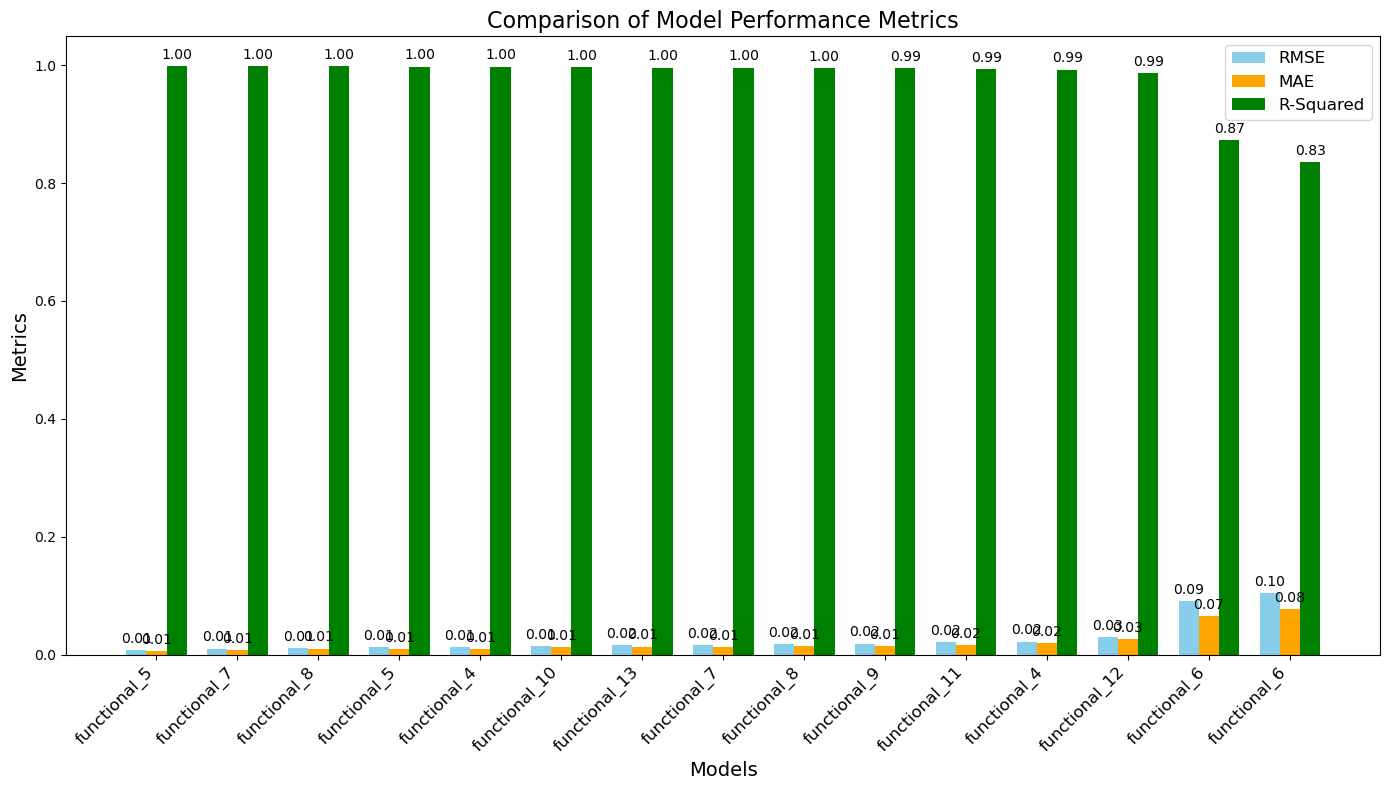

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure `results_df` contains your performance metrics as a pandas DataFrame
# with columns: 'Model', 'RMSE', 'MAE', 'R-Square'

# Set positions for bars
x = np.arange(len(results_df['Model']))  # the label locations
width = 0.25  # the width of the bars

# Create the bar plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot RMSE
bars_rmse = ax.bar(x - width, results_df['RMSE'], width, label='RMSE', color='skyblue')

# Plot MAE
bars_mae = ax.bar(x, results_df['MAE'], width, label='MAE', color='orange')

# Plot R-Squared (scaled for better visualization)
bars_r2 = ax.bar(x + width, results_df['R-Square'], width, label='R-Squared', color='green')

# Add text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Models', fontsize=14)
ax.set_ylabel('Metrics', fontsize=14)
ax.set_title('Comparison of Model Performance Metrics', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=12)
ax.legend(fontsize=12)

# Annotate bar values
def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

annotate_bars(bars_rmse)
annotate_bars(bars_mae)
annotate_bars(bars_r2)

# Adjust layout
fig.tight_layout()

# Show the plot
plt.show()

In [20]:
# Define models with corresponding names
model_names = [
    'LSTM-Transformer',
    'LSTM-CNN',
    'Transformer-LSTM',
    'CNN-LSTM',
    'CNN-Transformer',
    'Transformer-CNN',
    'CNN-LSTM-Transformer',
    'LSTM-CNN-Transformer',
    'CNN-Transformer-LSTM',
    'LSTM-Transformer-CNN',
    'Transformer-CNN-LSTM',
    'Transformer-LSTM-CNN'
]

# Collect results into a DataFrame with explicit model names
results = {'Model': [], 'RMSE': [], 'MAE': [], 'R-Square': []}

for name, model in zip(model_names, models):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)

    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results['Model'].append(name)
    results['RMSE'].append(rmse)
    results['MAE'].append(mae)
    results['R-Square'].append(r2)

# Convert results to a DataFrame
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

Training and evaluating model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating model: Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating model: Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating model: LSTM-CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training and evaluating model: CNN-Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training and evaluating model: LSTM-Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.010718  0.997431  0.012943
1              LSTM-CNN  0.004722  0.999446 

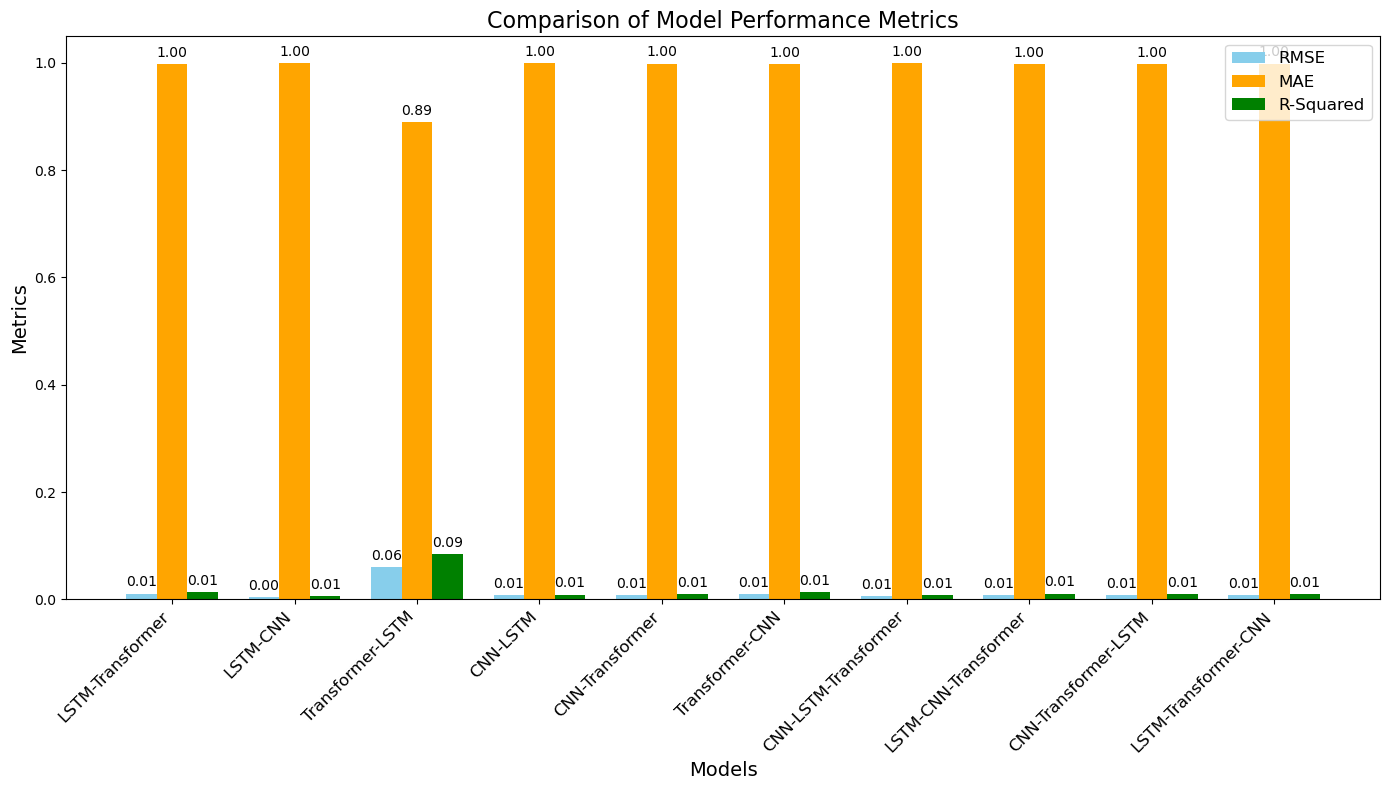

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Set positions for bars
x = np.arange(len(results_df['Model']))  # the label locations
width = 0.25  # the width of the bars

# Create the bar plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot RMSE
bars_rmse = ax.bar(x - width, results_df['RMSE'], width, label='RMSE', color='skyblue')

# Plot MAE
bars_mae = ax.bar(x, results_df['MAE'], width, label='MAE', color='orange')

# Plot R-Squared (scaled for better visualization)
bars_r2 = ax.bar(x + width, results_df['R-Square'], width, label='R-Squared', color='green')

# Add text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Models', fontsize=14)
ax.set_ylabel('Metrics', fontsize=14)
ax.set_title('Comparison of Model Performance Metrics', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=12)
ax.legend(fontsize=12)

# Annotate bar values
def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

annotate_bars(bars_rmse)
annotate_bars(bars_mae)
annotate_bars(bars_r2)

# Adjust layout
fig.tight_layout()

# Show the plot
plt.show()

## COMPARISON 2( WITH ADAM OPTIMIZER)

Training and evaluating model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Training and evaluating model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Training and evaluating model: Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Training and evaluating model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Training and evaluating model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Training and evaluating model: Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Training and evaluating model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Training and evaluating model: LSTM-CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Training and evaluating model: CNN-Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Training and evaluating model: LSTM-Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.202924  0.167440  0.368569
1              LSTM-CNN  0.195875 

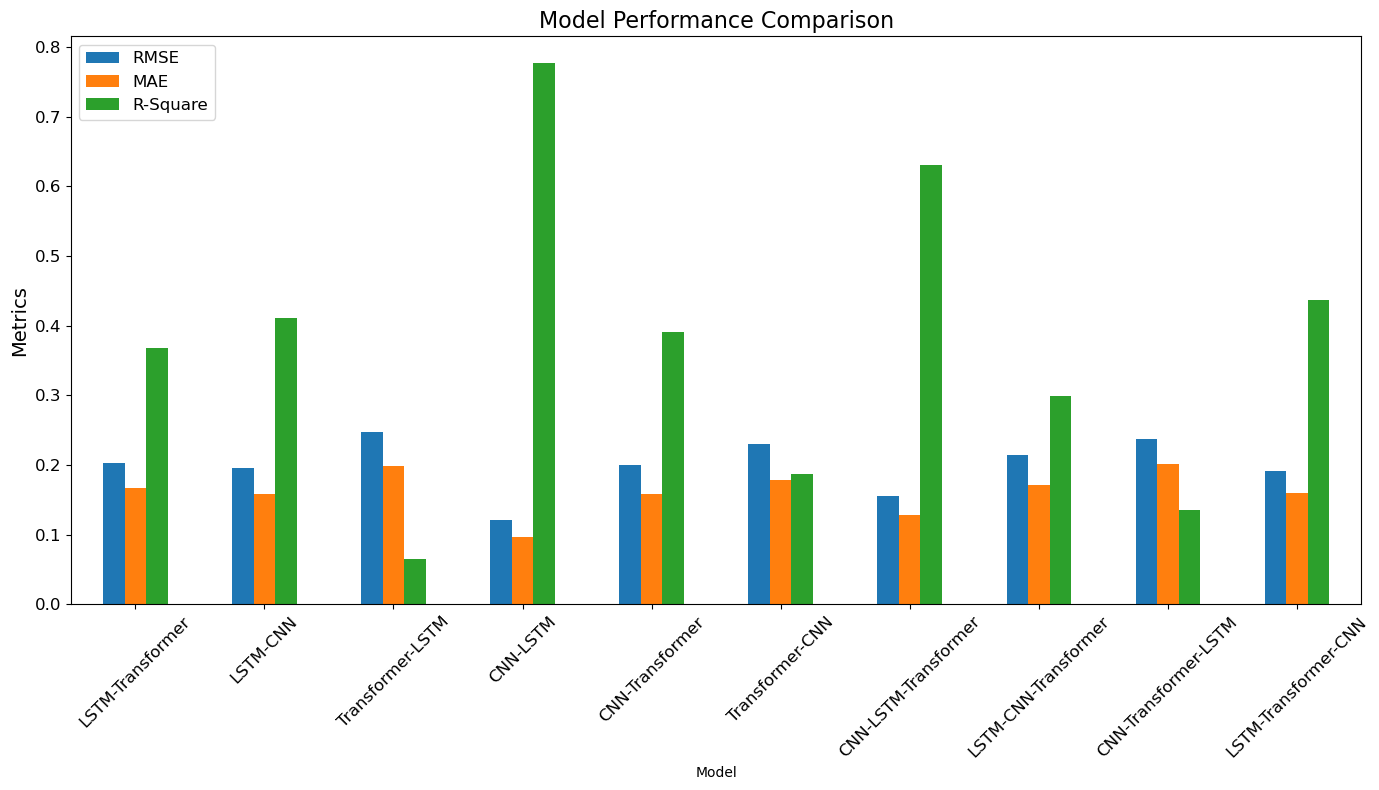

In [22]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Conv1D, Flatten, Reshape, Dropout, LayerNormalization, MultiHeadAttention
)
from tensorflow.keras.optimizers import Adam

# Define hybrid models
def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    transformer_output = Reshape((transformer_output.shape[1], 1))(transformer_output)
    lstm_output = LSTM(64)(transformer_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(transformer_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    transformer_output = Reshape((transformer_output.shape[1], 1))(transformer_output)
    lstm_output = LSTM(64)(transformer_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(transformer_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
    return model

# Dataset preparation
# Assuming data is preprocessed into X_train_reshaped, y_train, X_test_reshaped, y_test

# Define models and their names
models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_transformer_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_lstm_transformer_cnn((X_train_reshaped.shape[1], 1)),
]

model_names = [
    "LSTM-Transformer",
    "LSTM-CNN",
    "Transformer-LSTM",
    "CNN-LSTM",
    "CNN-Transformer",
    "Transformer-CNN",
    "CNN-LSTM-Transformer",
    "LSTM-CNN-Transformer",
    "CNN-Transformer-LSTM",
    "LSTM-Transformer-CNN",
]

# Evaluate models
results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

for name, model in zip(model_names, models):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results["Model"].append(name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    results["R-Square"].append(r2)

# Plotting results
results_df = pd.DataFrame(results)
print(results_df)

# Bar plot for comparison
results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Model Performance Comparison", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

# NADAM AS AN OPTIMIZER

/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training and evaluating model: LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Training and evaluating model: CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Training and evaluating model: RNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step 
Training and evaluating model: Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
         Model      RMSE       MAE  R-Square
0         LSTM  0.135608  0.109549  0.718009
1          CNN  0.249874  0.191876  0.042582
2          RNN  0.047480  0.041033  0.965431
3  Transformer  0.127185  0.110701  0.751955


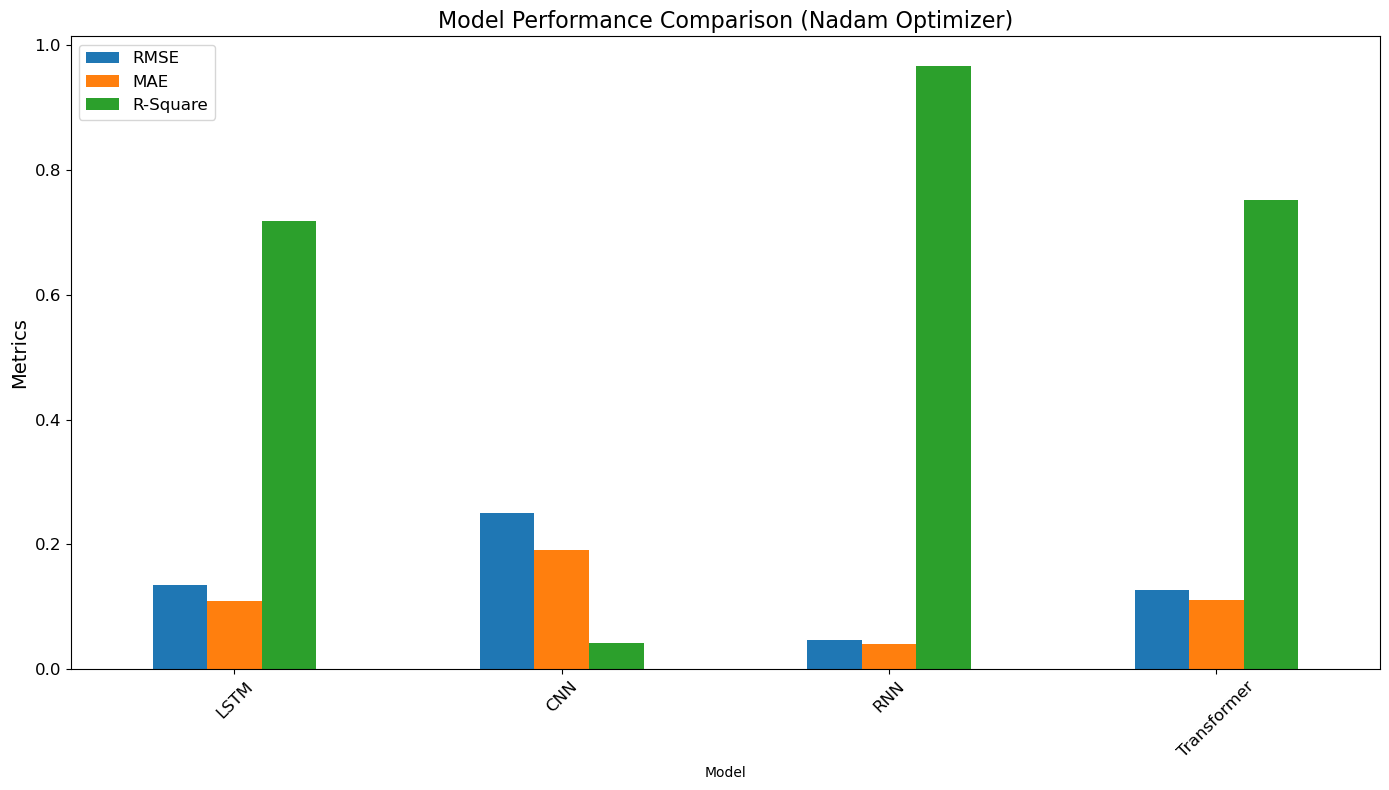

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Input, MultiHeadAttention, Reshape
from tensorflow.keras.optimizers import Nadam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define individual models using Nadam optimizer
def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn(input_shape):
    model = Sequential()
    model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_rnn(input_shape):
    model = Sequential()
    model.add(SimpleRNN(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

# Dataset preparation
# Assuming data is preprocessed into X_train_reshaped, y_train, X_test_reshaped, y_test

models = [
    build_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn((X_train_reshaped.shape[1], 1)),
    build_rnn((X_train_reshaped.shape[1], 1)),
    build_transformer((X_train_reshaped.shape[1], 1)),
]

model_names = [
    "LSTM",
    "CNN",
    "RNN",
    "Transformer",
]

# Evaluate models
results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

for name, model in zip(model_names, models):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results["Model"].append(name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    results["R-Square"].append(r2)

# Plotting results
results_df = pd.DataFrame(results)
print(results_df)

# Bar plot for comparison
results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Model Performance Comparison (Nadam Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

# HYBRID

Training and evaluating hybrid model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Training and evaluating hybrid model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Training and evaluating hybrid model: Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Training and evaluating hybrid model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Training and evaluating hybrid model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Training and evaluating hybrid model: Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Training and evaluating hybrid model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Training and evaluating hybrid model: LSTM-CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.158791  0.138202  0.613356
1              LSTM-CNN  0.153735  0.128107  0.637583
2      Transformer-LSTM  0.178830  0.151763  0.509609
3              CNN-LSTM  0.125429  0.097638  0.758

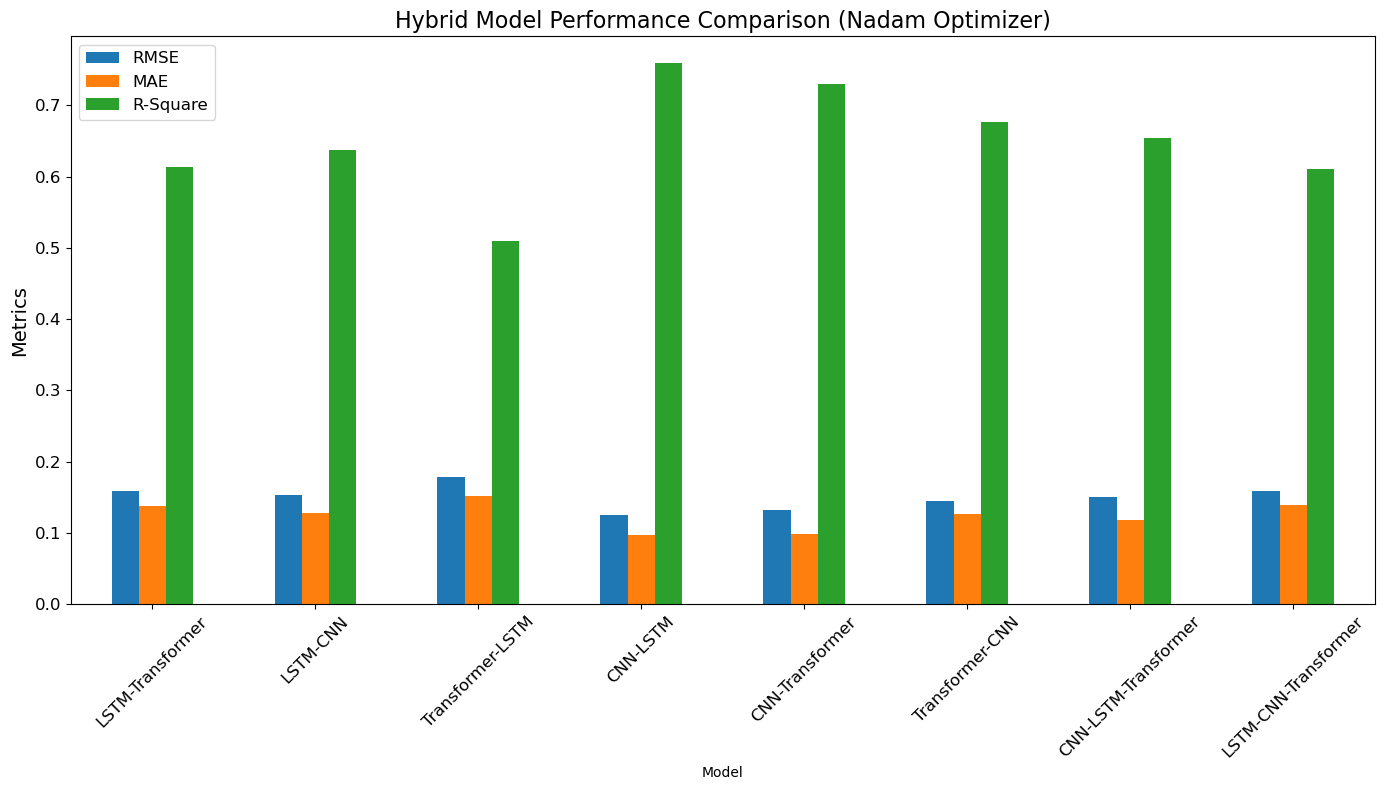

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, Reshape, MultiHeadAttention
from tensorflow.keras.optimizers import Nadam

# Define hybrid models with Nadam optimizer

def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    transformer_output = Reshape((transformer_output.shape[1], 1))(transformer_output)
    lstm_output = LSTM(64)(transformer_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(transformer_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mae'])
    return model

# Define all hybrid models in a list
hybrid_models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_transformer_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn_transformer((X_train_reshaped.shape[1], 1)),
]

hybrid_model_names = [
    "LSTM-Transformer",
    "LSTM-CNN",
    "Transformer-LSTM",
    "CNN-LSTM",
    "CNN-Transformer",
    "Transformer-CNN",
    "CNN-LSTM-Transformer",
    "LSTM-CNN-Transformer",
]

# Evaluate hybrid models
hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

for name, model in zip(hybrid_model_names, hybrid_models):
    print(f"Training and evaluating hybrid model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)

# Plotting hybrid model results
hybrid_results_df = pd.DataFrame(hybrid_results)
print(hybrid_results_df)

# Bar plot for comparison
hybrid_results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Hybrid Model Performance Comparison (Nadam Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

# ADAMAX AS AN OPTIMIZER

/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training and evaluating model: LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Training and evaluating model: CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Training and evaluating model: RNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Training and evaluating model: Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
         Model      RMSE       MAE  R-Square
0         LSTM  0.200097  0.168089  0.386040
1          CNN  0.427888  0.396120 -1.807501
2          RNN  0.093195  0.077030  0.866817
3  Transformer  0.282100  0.208863 -0.220298


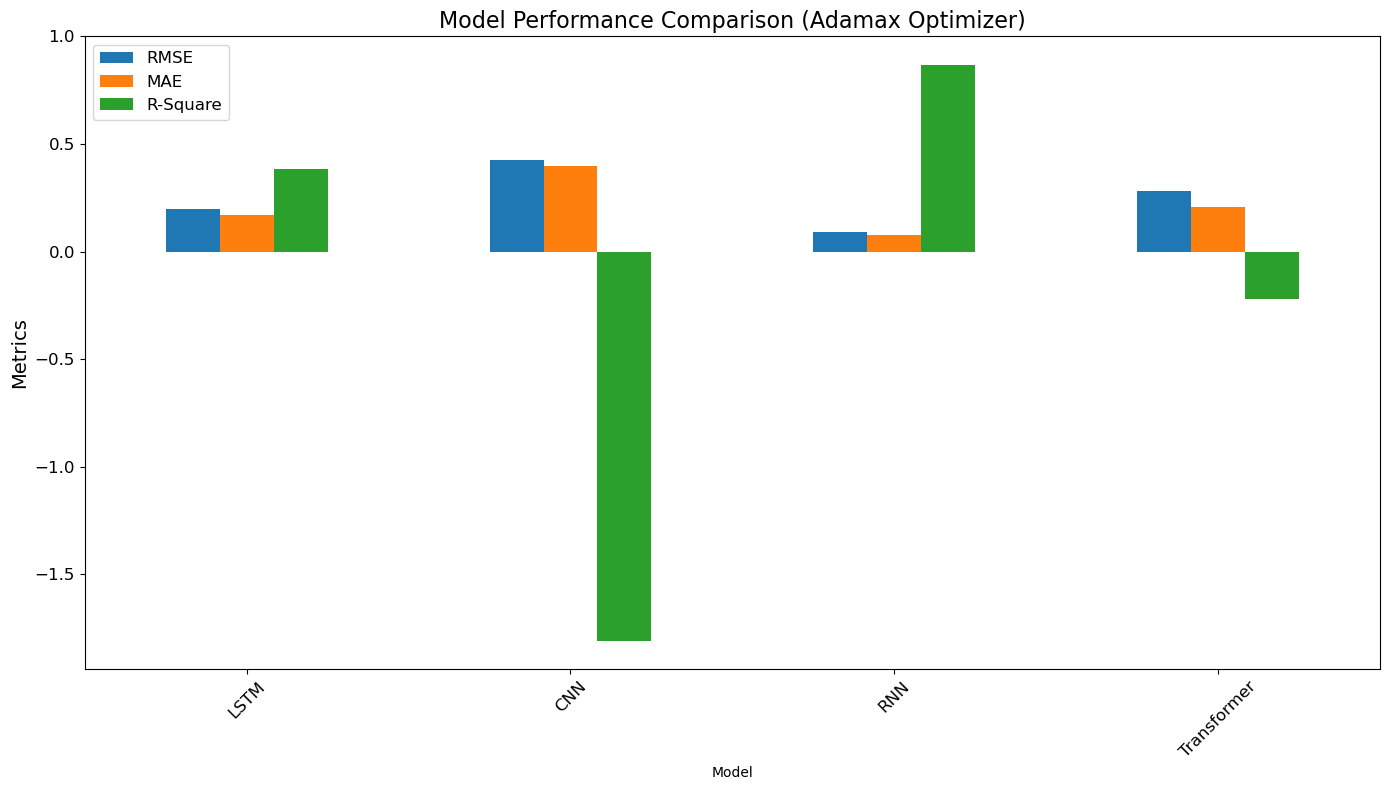

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Input, MultiHeadAttention, SimpleRNN
from tensorflow.keras.optimizers import Adamax
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define individual models using Adamax optimizer
def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn(input_shape):
    model = Sequential()
    model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_rnn(input_shape):
    model = Sequential()
    model.add(SimpleRNN(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

# Dataset preparation
# Assuming data is preprocessed into X_train_reshaped, y_train, X_test_reshaped, y_test

models = [
    build_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn((X_train_reshaped.shape[1], 1)),
    build_rnn((X_train_reshaped.shape[1], 1)),
    build_transformer((X_train_reshaped.shape[1], 1)),
]

model_names = [
    "LSTM",
    "CNN",
    "RNN",
    "Transformer",
]

# Evaluate models
results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

for name, model in zip(model_names, models):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results["Model"].append(name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    results["R-Square"].append(r2)

# Plotting results
results_df = pd.DataFrame(results)
print(results_df)

# Bar plot for comparison
results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Model Performance Comparison (Adamax Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

## HYBRID

Training and evaluating hybrid model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Training and evaluating hybrid model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Training and evaluating hybrid model: Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Training and evaluating hybrid model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Training and evaluating hybrid model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Training and evaluating hybrid model: Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Training and evaluating hybrid model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Training and evaluating hybrid model: LSTM-CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.217082  0.185771  0.277386
1              LSTM-CNN  0.196322  0.160892  0.408985
2      Transformer-LSTM  0.259989  0.216135 -0.036501
3              CNN-LSTM  0.189140  0.150603  0.451

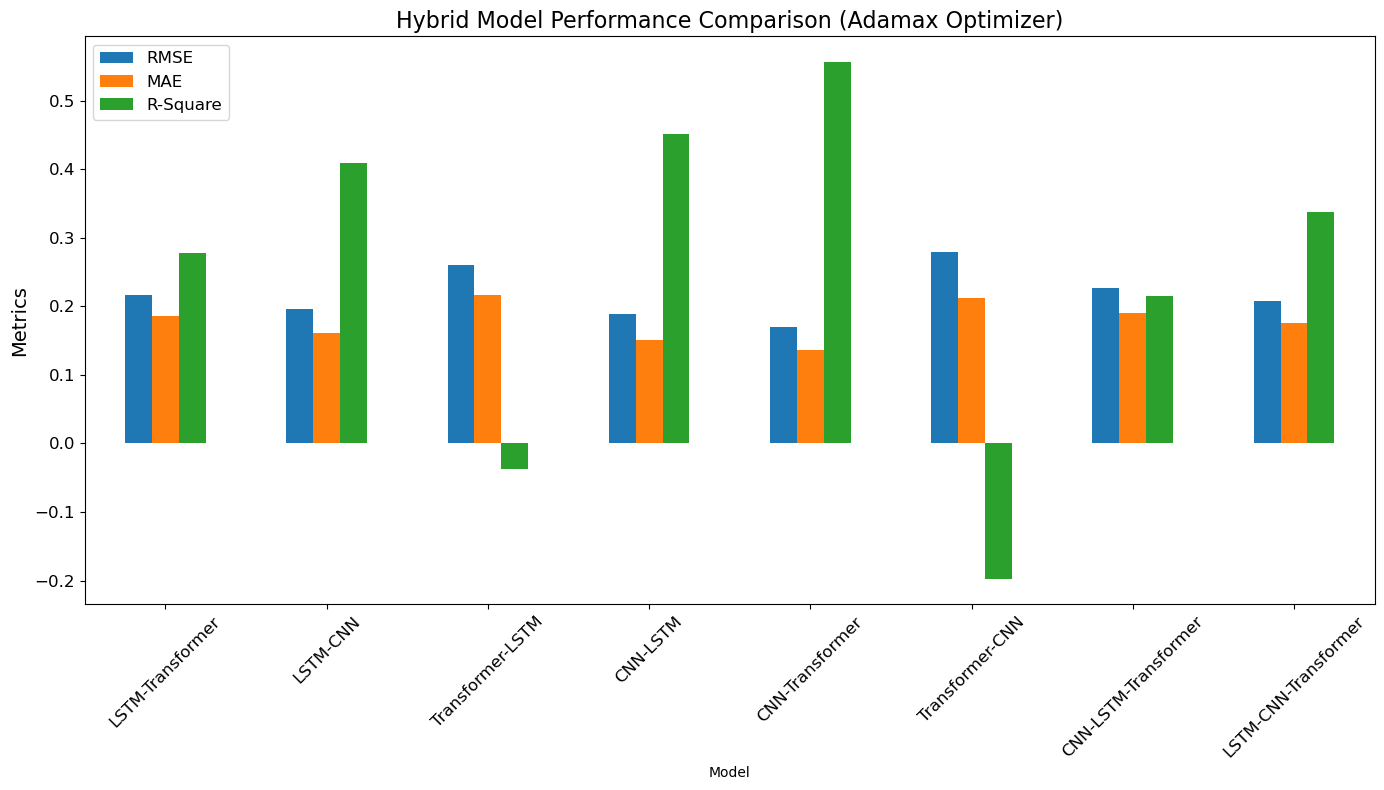

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, Reshape, MultiHeadAttention
from tensorflow.keras.optimizers import Adamax

# Define hybrid models with Adamax optimizer

def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    transformer_output = Reshape((transformer_output.shape[1], 1))(transformer_output)
    lstm_output = LSTM(64)(transformer_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(transformer_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adamax(), loss='mean_squared_error', metrics=['mae'])
    return model

# Define all hybrid models in a list
hybrid_models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_transformer_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn_transformer((X_train_reshaped.shape[1], 1)),
]

hybrid_model_names = [
    "LSTM-Transformer",
    "LSTM-CNN",
    "Transformer-LSTM",
    "CNN-LSTM",
    "CNN-Transformer",
    "Transformer-CNN",
    "CNN-LSTM-Transformer",
    "LSTM-CNN-Transformer",
]

# Evaluate hybrid models
hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

for name, model in zip(hybrid_model_names, hybrid_models):
    print(f"Training and evaluating hybrid model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)

# Plotting hybrid model results
hybrid_results_df = pd.DataFrame(hybrid_results)
print(hybrid_results_df)

# Bar plot for comparison
hybrid_results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Hybrid Model Performance Comparison (Adamax Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

# RMSprop AS AN OPTIMIZER

/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training and evaluating model: LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Training and evaluating model: CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Training and evaluating model: RNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Training and evaluating model: Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
         Model      RMSE       MAE  R-Square
0         LSTM  0.146807  0.116189  0.669515
1          CNN  0.151690  0.123186  0.647162
2          RNN  0.131409  0.126461  0.735205
3  Transformer  0.146986  0.121801  0.668706


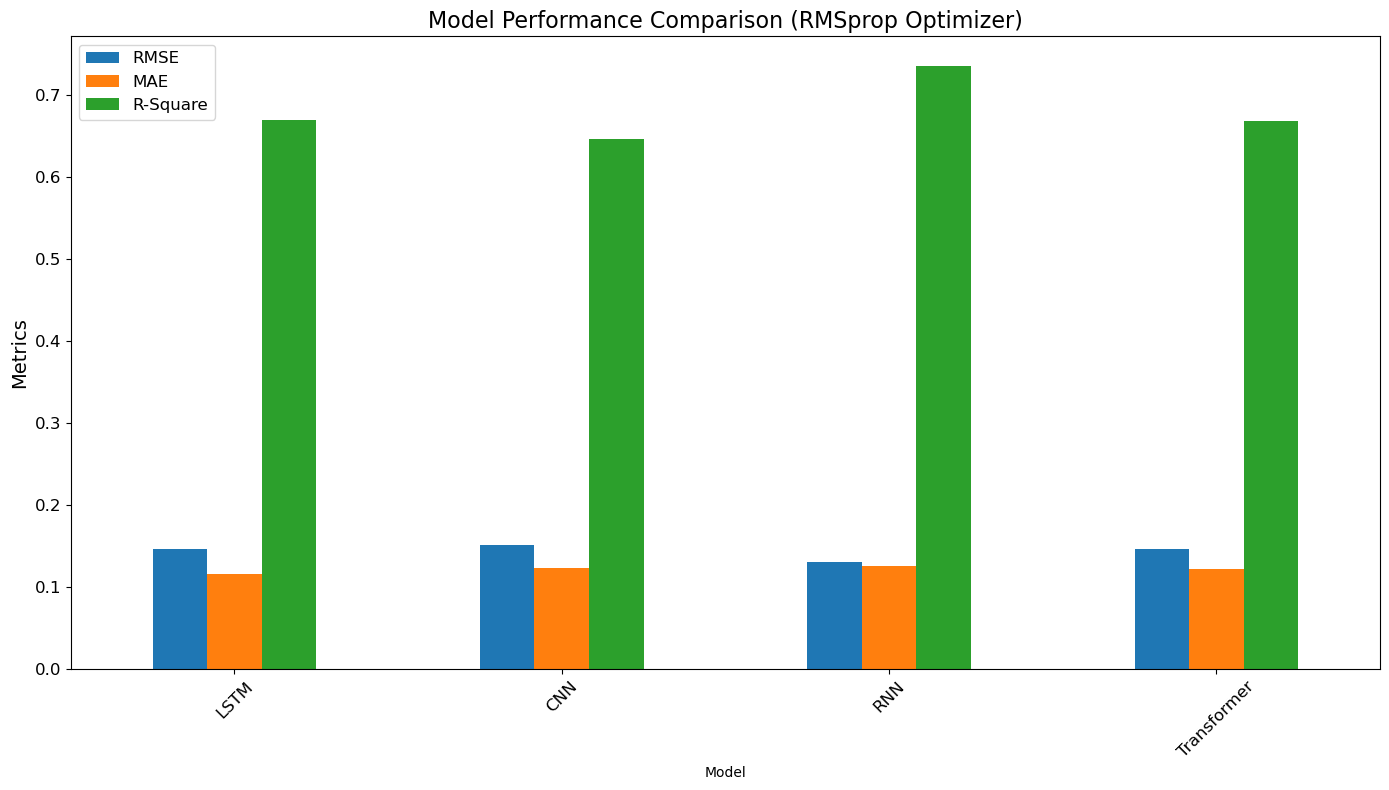

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Input, MultiHeadAttention, SimpleRNN
from tensorflow.keras.optimizers import RMSprop
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define individual models using RMSprop optimizer
def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn(input_shape):
    model = Sequential()
    model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_rnn(input_shape):
    model = Sequential()
    model.add(SimpleRNN(64, input_shape=input_shape, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

# Dataset preparation
# Assuming data is preprocessed into X_train_reshaped, y_train, X_test_reshaped, y_test

models = [
    build_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn((X_train_reshaped.shape[1], 1)),
    build_rnn((X_train_reshaped.shape[1], 1)),
    build_transformer((X_train_reshaped.shape[1], 1)),
]

model_names = [
    "LSTM",
    "CNN",
    "RNN",
    "Transformer",
]

# Evaluate models
results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

for name, model in zip(model_names, models):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results["Model"].append(name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    results["R-Square"].append(r2)

# Plotting results
results_df = pd.DataFrame(results)
print(results_df)

# Bar plot for comparison
results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Model Performance Comparison (RMSprop Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

## HYBRID

Training and evaluating hybrid model: LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Training and evaluating hybrid model: LSTM-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Training and evaluating hybrid model: Transformer-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Training and evaluating hybrid model: CNN-LSTM
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Training and evaluating hybrid model: CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Training and evaluating hybrid model: Transformer-CNN
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Training and evaluating hybrid model: CNN-LSTM-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Training and evaluating hybrid model: LSTM-CNN-Transformer
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
                  Model      RMSE       MAE  R-Square
0      LSTM-Transformer  0.165421  0.137314  0.580395
1              LSTM-CNN  0.160616  0.129939  0.604416
2      Transformer-LSTM  0.197730  0.171696  0.400479
3              CNN-LSTM  0.143126  0.113073  0.685

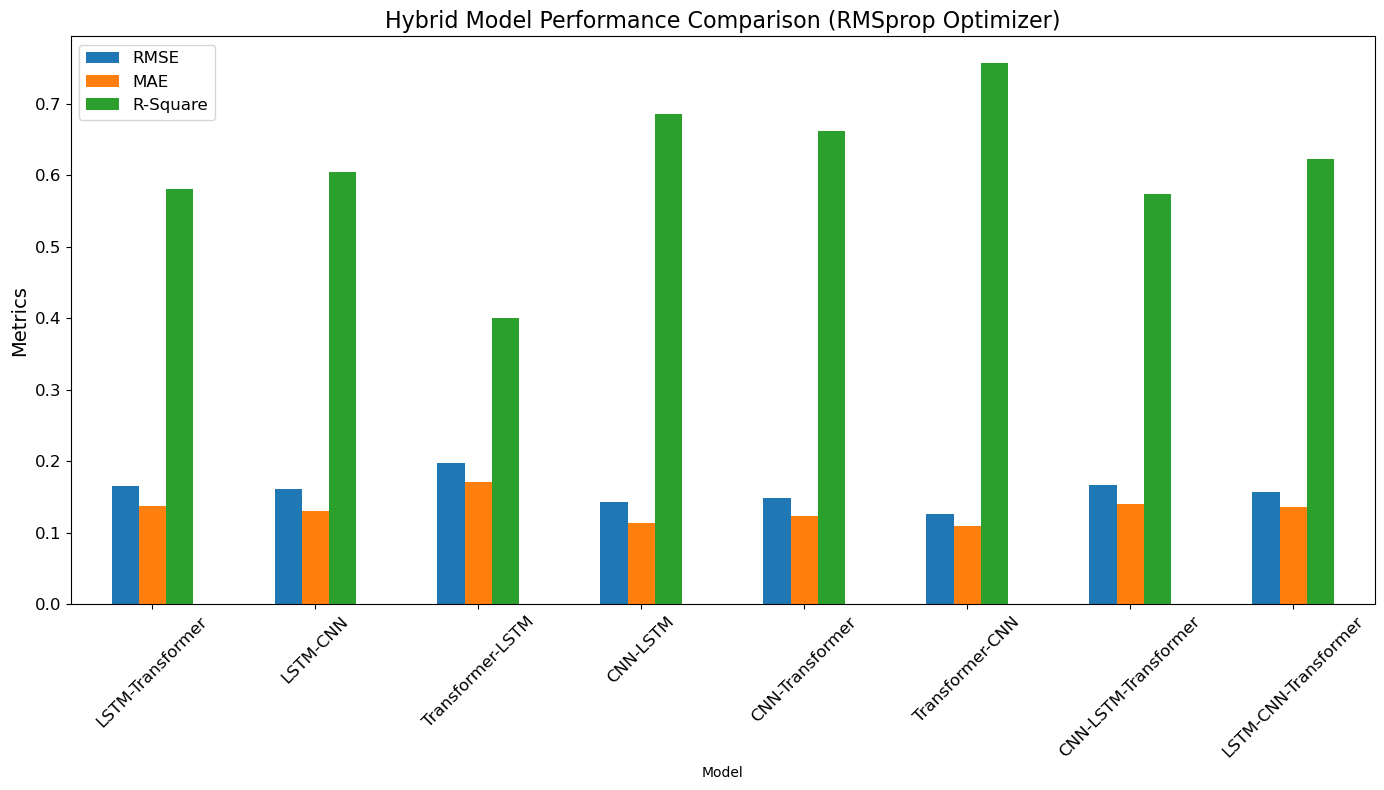

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, Reshape, MultiHeadAttention
from tensorflow.keras.optimizers import RMSprop

# Define hybrid models with RMSprop optimizer

def build_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_lstm(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    transformer_output = Reshape((transformer_output.shape[1], 1))(transformer_output)
    lstm_output = LSTM(64)(transformer_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64)(cnn_output)
    outputs = Dense(1)(lstm_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer_cnn(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(transformer_output)
    cnn_output = Flatten()(cnn_output)
    outputs = Dense(1)(cnn_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_lstm_transformer(input_shape):
    inputs = Input(shape=input_shape)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(inputs)
    lstm_output = LSTM(64, return_sequences=True)(cnn_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_output, lstm_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_cnn_transformer(input_shape):
    inputs = Input(shape=input_shape)
    lstm_output = LSTM(64, return_sequences=True)(inputs)
    cnn_output = Conv1D(32, kernel_size=2, activation='relu')(lstm_output)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(cnn_output, cnn_output)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=RMSprop(), loss='mean_squared_error', metrics=['mae'])
    return model

# Define all hybrid models
hybrid_models = [
    build_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn((X_train_reshaped.shape[1], 1)),
    build_transformer_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm((X_train_reshaped.shape[1], 1)),
    build_cnn_transformer((X_train_reshaped.shape[1], 1)),
    build_transformer_cnn((X_train_reshaped.shape[1], 1)),
    build_cnn_lstm_transformer((X_train_reshaped.shape[1], 1)),
    build_lstm_cnn_transformer((X_train_reshaped.shape[1], 1)),
]

hybrid_model_names = [
    "LSTM-Transformer",
    "LSTM-CNN",
    "Transformer-LSTM",
    "CNN-LSTM",
    "CNN-Transformer",
    "Transformer-CNN",
    "CNN-LSTM-Transformer",
    "LSTM-CNN-Transformer",
]

# Evaluate hybrid models
hybrid_results = {"Model": [], "RMSE": [], "MAE": [], "R-Square": []}

for name, model in zip(hybrid_model_names, hybrid_models):
    print(f"Training and evaluating hybrid model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    y_pred = y_pred.squeeze()  # Ensure y_pred is 1D
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    hybrid_results["Model"].append(name)
    hybrid_results["RMSE"].append(rmse)
    hybrid_results["MAE"].append(mae)
    hybrid_results["R-Square"].append(r2)

# Plotting hybrid model results
hybrid_results_df = pd.DataFrame(hybrid_results)
print(hybrid_results_df)

# Bar plot for comparison
hybrid_results_df.set_index("Model").plot(kind="bar", figsize=(14, 8), rot=45, fontsize=12)
plt.title("Hybrid Model Performance Comparison (RMSprop Optimizer)", fontsize=16)
plt.ylabel("Metrics", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

# AMSGrad AS AN OPTIMIZER

Training and evaluating model: LSTM
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Training and evaluating model: CNN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Training and evaluating model: RNN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Training and evaluating model: Transformer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


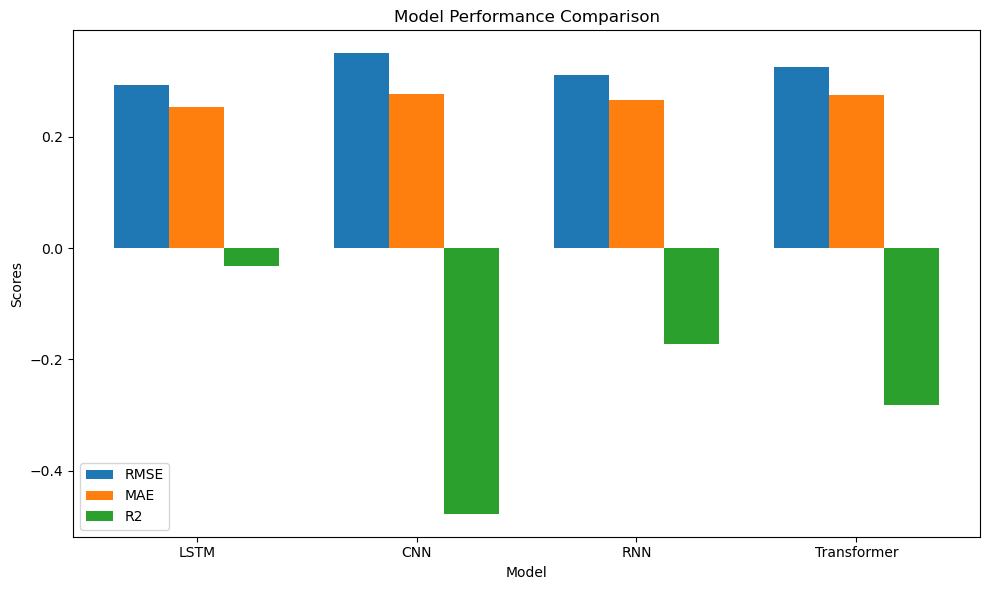

In [33]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Input, SimpleRNN, MultiHeadAttention
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define individual models using Adam(amsgrad=True) optimizer

def build_lstm(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))  # Explicitly define input shape
    model.add(LSTM(64, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))  # Explicitly define input shape
    model.add(Conv1D(32, kernel_size=3, activation='relu'))
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

def build_rnn(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))  # Explicitly define input shape
    model.add(SimpleRNN(64, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    transformer_output = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    transformer_output = Flatten()(transformer_output)
    outputs = Dense(1)(transformer_output)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(amsgrad=True), loss='mean_squared_error', metrics=['mae'])
    return model

# Model Evaluation Function
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Example data generation for illustration
np.random.seed(0)
X_train = pd.DataFrame(np.random.rand(100, 7))  # Replace with your actual training data
X_test = pd.DataFrame(np.random.rand(30, 7))  # Replace with your actual testing data
y_train = np.random.rand(100)  # Replace with your actual training labels
y_test = np.random.rand(30)  # Replace with your actual testing labels

# Reshape data for models
X_train_reshaped = X_train.to_numpy().reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_reshaped = X_test.to_numpy().reshape((X_test.shape[0], X_test.shape[1], 1))

# Model training and evaluation
results = {
    'Model': [],
    'RMSE': [],
    'MAE': [],
    'R2': []
}

# Iterate over models to train and evaluate
for name, model in zip(
    ['LSTM', 'CNN', 'RNN', 'Transformer'], 
    [
        build_lstm((X_train_reshaped.shape[1], X_train_reshaped.shape[2])), 
        build_cnn((X_train_reshaped.shape[1], X_train_reshaped.shape[2])), 
        build_rnn((X_train_reshaped.shape[1], X_train_reshaped.shape[2])), 
        build_transformer((X_train_reshaped.shape[1], X_train_reshaped.shape[2]))
    ]
):
    print(f"Training and evaluating model: {name}")
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped).squeeze()  # Ensure y_pred is 1D

    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results['Model'].append(name)
    results['RMSE'].append(rmse)
    results['MAE'].append(mae)
    results['R2'].append(r2)

# Convert results to a pandas dataframe
results_df = pd.DataFrame(results)

# Plotting comparison using clustered bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.25
index = np.arange(len(results_df))

bar1 = ax.bar(index, results_df['RMSE'], bar_width, label='RMSE')
bar2 = ax.bar(index + bar_width, results_df['MAE'], bar_width, label='MAE')
bar3 = ax.bar(index + 2 * bar_width, results_df['R2'], bar_width, label='R2')

ax.set_xlabel('Model')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(results_df['Model'])
ax.legend()

plt.tight_layout()
plt.show()
